In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [4]:
df_DA_DE = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'Germany')].copy()
df_DA_DE = df_DA_DE.dropna(subset=['salary_year_avg'])


In [6]:
df_DA_DE = df_DA_DE.explode('job_skills')
df_DA_DE[['salary_year_avg','job_skills']]

,salary_year_avg,job_skills
20066,75067.5,r
20066,75067.5,python
20066,75067.5,java
20066,75067.5,c#
20066,75067.5,sql
...,...,...
770282,166419.5,tableau
770282,166419.5,terraform
781105,111175.0,python
781105,111175.0,pyspark


In [27]:
df_DA_group = df_DA_DE.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])
df_DA_top_pay = df_DA_group.sort_values(by='median', ascending=False).head(10)
df_DA_Skills = df_DA_group.sort_values(by='count', ascending=False).head(10).sort_values(by='median', ascending=False)
 

In [12]:
df_DA_top_pay 

,count,median
job_skills,,
github,3,199675.0
terraform,1,166419.5
bigquery,1,166419.5
redshift,1,166419.5
nosql,1,166419.5
kafka,1,166419.5
gcp,3,165000.0
javascript,1,111175.0
terminal,1,111175.0


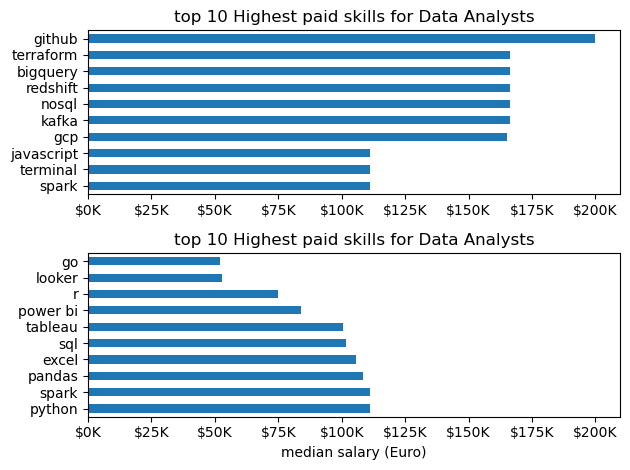

In [38]:
fig, ax = plt.subplots(2,1)

df_DA_top_pay.plot(kind='barh', y='median', ax=ax[0], legend=False)
ax[0].invert_yaxis()
ax[0].set_title('top 10 Highest paid skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
from matplotlib.ticker import FuncFormatter
ax[0].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${int(x/1000)}K'))


df_DA_Skills.plot(kind='barh', y='median', ax=ax[1],legend=False)
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_title('top 10 Highest paid skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('median salary (Euro)')
ax[1].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
fig.tight_layout()


